# 4주차: 모델은 어떤 분자에서 틀리는가?

3주차는 GNN이 **언제** 무너지는지 답했습니다. Nearest-train Tanimoto similarity가 0.4 아래로
떨어지면 GCN/GIN은 평균 예측 수준으로 붕괴합니다. 남은 질문은 두 개입니다.

> **어떤 분자에서** 틀리는가? 그리고 그 실패는 **어려운 화학** 때문인가, **표현 방식** 때문인가?

이번 주는 leaderboard를 떠납니다. 새로 학습하지 않고, 3주차가 남긴 분자 단위 예측값을
molecular property와 대조해 prediction error를 **데이터에 대한 진단 도구**로 씁니다.

분자마다 $e_i = |\hat{y}_i - y_i|$ 를 구한 뒤 MolWt, logP, ring 수, heteroatom 수, 분자 크기,
scaffold와의 관계를 봅니다. 다만 그냥 산점도를 다섯 개 그리는 것으로는 답이 나오지 않습니다.
이 노트북은 세 개의 함정을 먼저 막아 둡니다.

1. **내재적 난이도 confound** — 큰 분자는 logS가 극단적이므로 오차가 큰 게 당연할 수 있습니다.
   `Dummy (mean)`의 오차(= $|y - \bar{y}_{train}|$)를 통제군으로 씁니다.
2. **다중공선성** — MolWt와 HeavyAtomCount는 Spearman 0.93입니다. 단일 상관은 식별되지 않습니다.
3. **과잉 주장** — 다변량 모델의 held-out $R^2$를 먼저 보고, 그 다음에만 순위를 읽습니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ai4sci_molecule.week1 import load_esol
from ai4sci_molecule.week3 import load_or_run_sweep
from ai4sci_molecule.week4 import (
    AnalysisConfig,
    bin_property_errors,
    build_error_profile,
    case_studies,
    effective_sample_sizes,
    error_property_importance,
    model_error_agreement,
    model_error_disagreement,
    molecular_properties,
    plot_case_study_structures,
    plot_error_property_importance,
    plot_model_error_agreement,
    plot_property_collinearity,
    plot_property_error_bins,
    plot_property_error_correlation,
    plot_residual_shrinkage,
    plot_scaffold_errors,
    property_bin_summary,
    property_collinearity,
    property_error_correlation,
    property_table,
    save_figures,
    scaffold_error_table,
    shrinkage_fit,
)

SEED = 42
CONFIG = AnalysisConfig()
DATA_DIRECTORY = Path("..") / "data" / "MoleculeNet"
WEEK3_DIRECTORY = Path("..") / "results" / "week3"
RESULTS_DIRECTORY = Path("..") / "results" / "week4"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "UnDotum"  # renders Hangul plot titles; DejaVu Sans lacks Hangul glyphs
plt.rcParams["axes.unicode_minus"] = False  # UnDotum lacks the unicode minus glyph
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

## 1. 3주차 예측 불러오기

이번 주는 **학습을 하지 않습니다**. 3주차 sweep 결과가 그대로 증거입니다. 캐시가 있으면 몇 초,
없으면 3주차 sweep을 먼저 돌립니다(GPU 약 10분).

In [2]:
dataset = load_esol(DATA_DIRECTORY)
smiles = [str(graph.smiles) for graph in dataset]
sweep = load_or_run_sweep(dataset, directory=WEEK3_DIRECTORY)
predictions = sweep.predictions

print(f"분자 수: {len(dataset):,}")
print(f"예측 행 수: {len(predictions):,}")
print(f"모델: {list(predictions['model'].unique())}")
print(f"split type: {list(predictions['split_type'].unique())}")

분자 수: 1,128
예측 행 수: 8,410
모델: ['Dummy (mean)', 'Linear', 'MLP', 'GCN', 'GIN']
split type: ['random', 'scaffold', 'scaffold_shuffled']


## 2. 유효 표본 수: 8,410행은 8,410개의 관측이 아니다

예측 행은 8,410개지만, 실제로는 몇 백 개의 분자를 seed 5개로 본 것입니다. 게다가 seed 축의
의미가 regime마다 다릅니다.

그래서 두 개의 regime을 정의합니다.

- `in_domain` ← `random` (leaky regime)
- `out_of_scaffold` ← `scaffold` + `scaffold_shuffled`

결정적 `scaffold` split 하나만 쓰면 test 분자가 113개, ≥3분자 scaffold가 8개뿐입니다.
`scaffold_shuffled`를 합치면 추가 학습 없이 둘 다 크게 늘어납니다. `random`은 leaky regime이므로
**섞지 않습니다** — 섞으면 in-domain과 out-of-domain 증거가 뒤엉킵니다.

In [3]:
sizes = effective_sample_sizes(predictions, minimum_molecules=CONFIG.minimum_scaffold_molecules)
sizes

,regime,split_types,seeds,rows_per_model,distinct_molecules,molecules_in_every_seed,mean_seeds_per_molecule,distinct_scaffolds,scaffolds_over_minimum
0,in_domain,random,5,565,470,0,1.202128,136,21
1,out_of_scaffold,scaffold + scaffold_shuffled,5,1117,413,113,2.496368,201,30


`out_of_scaffold`의 `molecules_in_every_seed`가 113이라는 점을 봐 두세요. 결정적 scaffold split의
그 113개만 seed 5개를 모두 갖고, 나머지는 1–3개입니다. 즉 대부분의 분자에서 per-molecule 오차는
학습 noise를 그대로 안고 있습니다.

## 3. 13개 molecular property

1주차의 descriptor 5개를 그대로 재사용하고 8개를 더합니다. 앞의 5개는 Linear/MLP의 **입력
feature**이기도 하므로, 그 모델들의 property–error 상관은 부분적으로 순환적입니다. 이 사실은
표의 `trained_on` 열로 계속 따라다닙니다.

In [4]:
molecular_properties(["CCO", "c1ccccc1", "c1ccc2ccccc2c1", "C1CCCCC1", "Clc1ccc(Cl)cc1"]).assign(
    smiles=["CCO", "c1ccccc1", "c1ccc2ccccc2c1", "C1CCCCC1", "Clc1ccc(Cl)cc1"]
).set_index("smiles")

,MolWt,MolLogP,TPSA,NumRotatableBonds,AromaticAtomFraction,HeavyAtomCount,NumRings,NumAromaticRings,NumAliphaticRings,NumHeteroatoms,FractionCSP3,NumHDonors,NumHAcceptors
smiles,,,,,,,,,,,,,
CCO,46.069,-0.0014,20.23,0.0,0.00,3.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
c1ccccc1,78.114,1.6866,0.00,0.0,1.00,6.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
c1ccc2ccccc2c1,128.174,2.8398,0.00,0.0,1.00,10.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
C1CCCCC1,84.162,2.3406,0.00,0.0,0.00,6.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
Clc1ccc(Cl)cc1,147.004,2.9934,0.00,0.0,0.75,8.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0


## 4. Property는 서로 독립이 아니다 — 단일 상관을 읽기 전에

이 절이 먼저 오는 이유는, 뒤에 나올 "MolWt와 오차가 상관있다"는 문장을 **미리 반쯤 무효화**하기
위해서입니다. MolWt가 커지면 HeavyAtomCount도 ring 수도 heteroatom 수도 같이 커집니다.

In [5]:
properties = property_table(predictions)
print(f"property를 계산한 분자 수: {len(properties)}")

collinearity = property_collinearity(properties)
print(f"|Spearman| > 0.6 인 property 쌍: {len(collinearity)}개")
collinearity.head(10)

property를 계산한 분자 수: 720
|Spearman| > 0.6 인 property 쌍: 12개


,property_a,property_b,spearman
0,TPSA,NumHAcceptors,0.935479
1,MolWt,HeavyAtomCount,0.933627
2,AromaticAtomFraction,NumAromaticRings,0.890738
3,AromaticAtomFraction,FractionCSP3,-0.872073
4,NumAromaticRings,FractionCSP3,-0.781421
5,HeavyAtomCount,NumRings,0.771139
6,NumHeteroatoms,NumHAcceptors,0.764277
7,TPSA,NumHeteroatoms,0.749026
8,MolWt,NumHeteroatoms,0.713597
9,TPSA,NumHDonors,0.692140


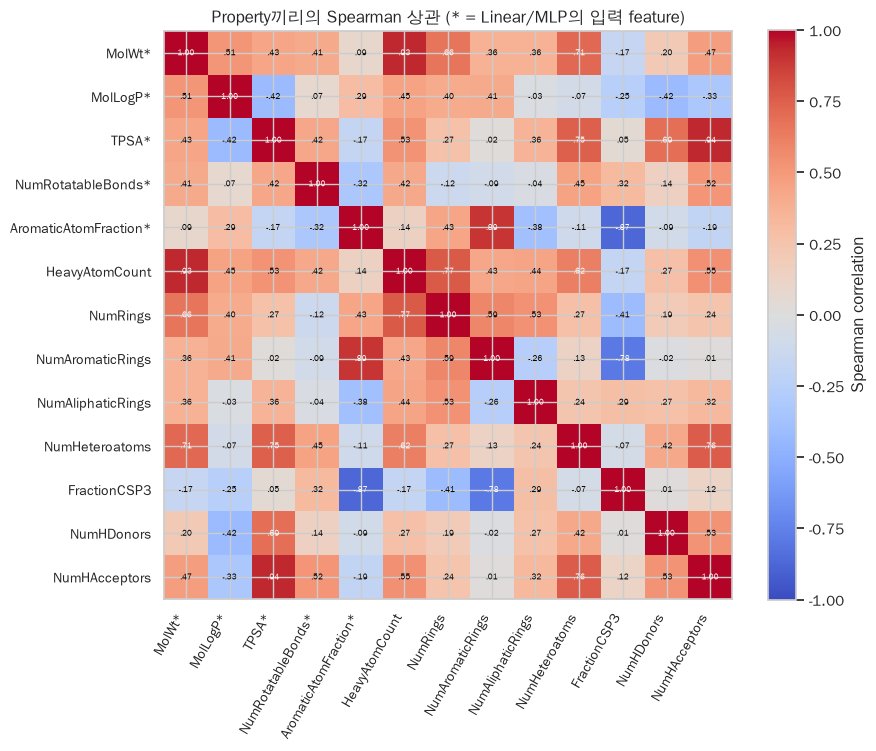

In [6]:
figure_collinearity = plot_property_collinearity(
    properties, title="Property끼리의 Spearman 상관 (* = Linear/MLP의 입력 feature)"
)
plt.show()

## 5. 분자마다 오차를 하나로 모으기

Seed 축을 평균해 분자 1행으로 만듭니다. 세 가지 규약을 확인해 두세요.

- `residual_mean = predicted − actual`. 사용자가 든 예(true −4.0, pred −1.7)는 residual **+2.3**,
  즉 모델이 분자를 실제보다 **잘 녹는다고** 예측한 것입니다.
- `baseline_absolute_error`는 `Dummy (mean)`의 오차입니다. Dummy의 예측은 (split, seed)마다
  train 평균 상수이므로, 이 값이 곧 $|y - \bar{y}_{train}|$ — **내재적 난이도**입니다.
- `normalized_error`는 그 비율입니다. train 평균에 앉은 분자(난이도 < 0.25 logS)는 분모가 너무
  작아 NaN으로 둡니다.

In [7]:
profile = build_error_profile(predictions, properties=properties)
print(f"profile 행 수: {len(profile):,}")

profile[
    [
        "regime",
        "model",
        "smiles",
        "actual",
        "predicted_mean",
        "residual_mean",
        "absolute_error",
        "baseline_absolute_error",
        "normalized_error",
        "MolWt",
    ]
].head(8)

profile 행 수: 4,415


,regime,model,smiles,actual,predicted_mean,residual_mean,absolute_error,baseline_absolute_error,normalized_error,MolWt
0,in_domain,Dummy (mean),CC(C#C)N(C)C(=O)Nc1ccc(Cl)cc1,-3.90,-3.05355,0.84645,0.84645,0.84645,1.0,236.702
1,in_domain,Dummy (mean),Clc1cccc(Cl)c1,-3.04,-3.05230,-0.01230,0.01230,0.01230,NaN,147.004
2,in_domain,Dummy (mean),CCCC/C=C/C,-3.82,-3.05230,0.76770,0.76770,0.76770,1.0,98.189
3,in_domain,Dummy (mean),CCCCBr,-2.37,-3.05230,-0.68230,0.68230,0.68230,1.0,137.020
4,in_domain,Dummy (mean),Cc1ccnc(C)c1,0.38,-3.06185,-3.44185,3.44185,3.44185,1.0,107.156
5,in_domain,Dummy (mean),Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O,-3.79,-3.05230,0.73770,0.73770,0.73770,1.0,354.815
6,in_domain,Dummy (mean),CC(O)C(C)(C)C,-0.62,-3.05230,-2.43230,2.43230,2.43230,1.0,102.177
7,in_domain,Dummy (mean),Oc1ccc(cc1)c2ccccc2,-3.48,-3.05230,0.42770,0.42770,0.42770,1.0,170.211


## 6. Property와 오차의 상관 — 그리고 통제군

세 개의 열을 **함께** 읽어야 합니다.

| 열 | 의미 |
|---|---|
| `spearman` | 날것의 상관 (+ bootstrap 95% CI) |
| `baseline_spearman` | 같은 축에서 **Dummy**의 상관 = 내재적 난이도 기울기 |
| `partial_spearman` | 난이도와 similarity를 통제한 뒤 남은 것 |

`in_domain`부터 봅니다.

In [8]:
correlations = property_error_correlation(
    profile, samples=CONFIG.bootstrap_samples, seed=CONFIG.seed
)

columns = [
    "property",
    "spearman",
    "ci_low",
    "ci_high",
    "excludes_zero",
    "baseline_spearman",
    "partial_spearman",
    "trained_on",
]
in_domain_gin = correlations[
    (correlations["regime"] == "in_domain") & (correlations["model"] == "GIN")
]
in_domain_gin[columns].sort_values("spearman", key=abs, ascending=False)

,property,spearman,ci_low,ci_high,excludes_zero,baseline_spearman,partial_spearman,trained_on
57,HeavyAtomCount,0.275439,0.189221,0.360995,True,-0.027771,0.299878,False
52,MolWt,0.265178,0.180204,0.351722,True,-0.054520,0.292103,True
58,NumRings,0.241289,0.153337,0.325415,True,0.003005,0.246858,False
61,NumHeteroatoms,0.238134,0.151585,0.323966,True,-0.068198,0.235165,False
59,NumAromaticRings,0.222074,0.126981,0.310260,True,0.020455,0.217630,False
64,NumHAcceptors,0.201998,0.116235,0.289653,True,-0.096590,0.203359,False
54,TPSA,0.174980,0.090637,0.264046,True,-0.117104,0.183155,True
62,FractionCSP3,-0.174250,-0.253653,-0.081565,True,0.017524,-0.169955,False
56,AromaticAtomFraction,0.157932,0.060223,0.248690,True,-0.005019,0.155637,True
53,MolLogP,0.105732,0.015410,0.194227,True,0.046111,0.141573,True


**여기가 사용자의 질문에 대한 답입니다.** `in_domain`에서 GIN의 오차는 분자 크기와 함께 커지고
(MolWt, HeavyAtomCount, NumRings, NumHeteroatoms), `FractionCSP3`가 높은 포화 분자에서는
작아집니다. 그리고 **Dummy의 상관은 전부 0 근처**입니다 — 난이도 때문이 아니라는 뜻입니다.
`partial_spearman`이 날것의 상관과 거의 같다는 점이 이를 한 번 더 확인해 줍니다.

이제 같은 표를 `out_of_scaffold`에서 봅니다. 해석이 뒤집힙니다.

In [9]:
out_of_scaffold_gin = correlations[
    (correlations["regime"] == "out_of_scaffold") & (correlations["model"] == "GIN")
]
out_of_scaffold_gin[columns].sort_values("baseline_spearman", key=abs, ascending=False)

,property,spearman,ci_low,ci_high,excludes_zero,baseline_spearman,partial_spearman,trained_on
118,MolLogP,0.103166,0.007685,0.200276,True,0.601696,0.072918,True
119,TPSA,-0.082283,-0.176245,0.013943,False,-0.378165,-0.112409,True
128,NumHDonors,-0.073970,-0.172399,0.022232,False,-0.375379,-0.051891,False
129,NumHAcceptors,-0.048146,-0.143401,0.044136,False,-0.339499,-0.094159,False
117,MolWt,0.063984,-0.037716,0.161653,False,0.291389,-0.020138,True
124,NumAromaticRings,0.036387,-0.062957,0.134043,False,0.199525,0.028459,False
122,HeavyAtomCount,0.005058,-0.093028,0.096048,False,0.188022,-0.050380,False
127,FractionCSP3,-0.039784,-0.141210,0.055890,False,-0.172314,-0.047166,False
123,NumRings,-0.050522,-0.148083,0.045276,False,0.140306,-0.047087,False
121,AromaticAtomFraction,0.036725,-0.061217,0.135092,False,0.139215,0.053439,True


**Dummy 정규화 없이는 정반대로 읽게 되는 지점입니다.** 골격이 낯선 regime에서 GIN의 property
상관은 전부 0 근처로 죽습니다. 순진하게 보면 "property와 오차는 무관하다"가 됩니다.

그런데 `baseline_spearman`을 보면 **Dummy는** logP(+0.60), TPSA(−0.38), NumHDonors(−0.38)와
강하게 상관합니다. 즉 이 test set에서 난이도 기울기는 뚜렷하게 존재하는데, GIN은 그 기울기와
무관하게 **어디서나 똑같이 나쁩니다**. 3주차의 "평균 예측 수준으로 붕괴"와 정확히 같은 현상을
property 축에서 다시 본 것입니다.

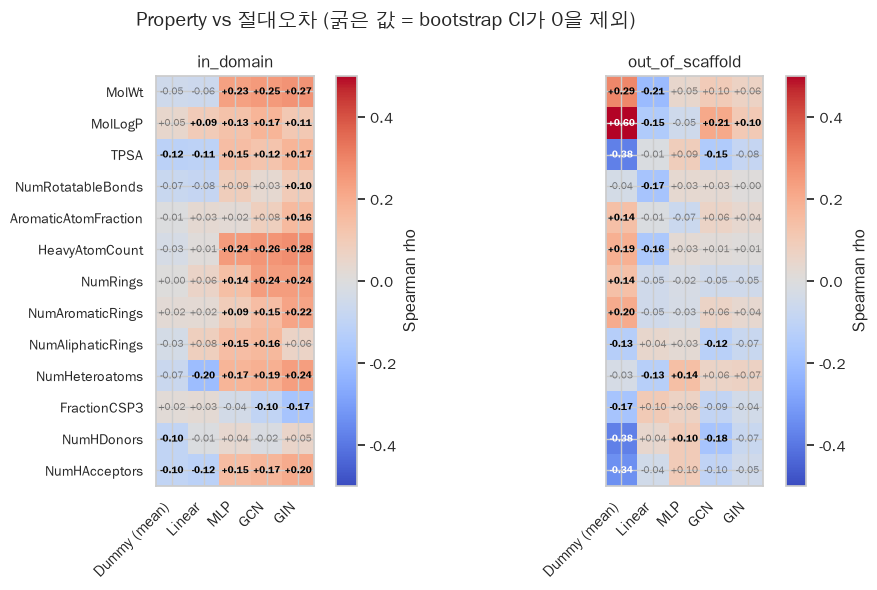

In [10]:
figure_correlation = plot_property_error_correlation(
    correlations, title="Property vs 절대오차 (굵은 값 = bootstrap CI가 0을 제외)"
)
plt.show()

## 7. 난이도를 걷어낸 구간별 오차

3주차 §7의 기법(모델 MAE ÷ Dummy MAE)을 property 축으로 옮깁니다. 구간은 사분위로 잘라
ESOL의 치우친 분포에서도 각 bin이 채워지게 합니다. 점선 1.0은 **평균 예측과 같은 수준**이고,
그 위는 평균을 찍는 것보다 못하다는 뜻입니다.

모든 집계는 **ratio-of-means**입니다. 분자별 비율을 평균하면 train 평균 근처 분자들이 표를
지배해 버립니다.

In [11]:
bins = bin_property_errors(profile, "MolWt", quantiles=CONFIG.property_quantiles)
bins[bins["regime"] == "in_domain"][
    [
        "model",
        "property_bin",
        "molecules",
        "property_median",
        "actual_median",
        "mean_absolute_error",
        "baseline_mean_absolute_error",
        "normalized_mean_absolute_error",
    ]
]

,model,property_bin,molecules,property_median,actual_median,mean_absolute_error,baseline_mean_absolute_error,normalized_mean_absolute_error
0,Dummy (mean),"(16.041999999999998, 116.174]",118,98.167,-1.050,2.103767,2.103767,1.000000
1,Dummy (mean),"(116.174, 179.689]",117,145.161,-2.310,1.200195,1.200195,1.000000
2,Dummy (mean),"(179.689, 271.382]",117,218.205,-3.220,1.519386,1.519386,1.000000
3,Dummy (mean),"(271.382, 780.949]",118,332.403,-4.689,2.033105,2.033105,1.000000
4,Linear,"(16.041999999999998, 116.174]",118,98.167,-1.050,0.864096,2.103767,0.410737
5,Linear,"(116.174, 179.689]",117,145.161,-2.310,0.663741,1.200195,0.553027
6,Linear,"(179.689, 271.382]",117,218.205,-3.220,0.832480,1.519386,0.547906
7,Linear,"(271.382, 780.949]",118,332.403,-4.689,0.690378,2.033105,0.339568
8,MLP,"(16.041999999999998, 116.174]",118,98.167,-1.050,0.491728,2.103767,0.233737
9,MLP,"(116.174, 179.689]",117,145.161,-2.310,0.511212,1.200195,0.425941


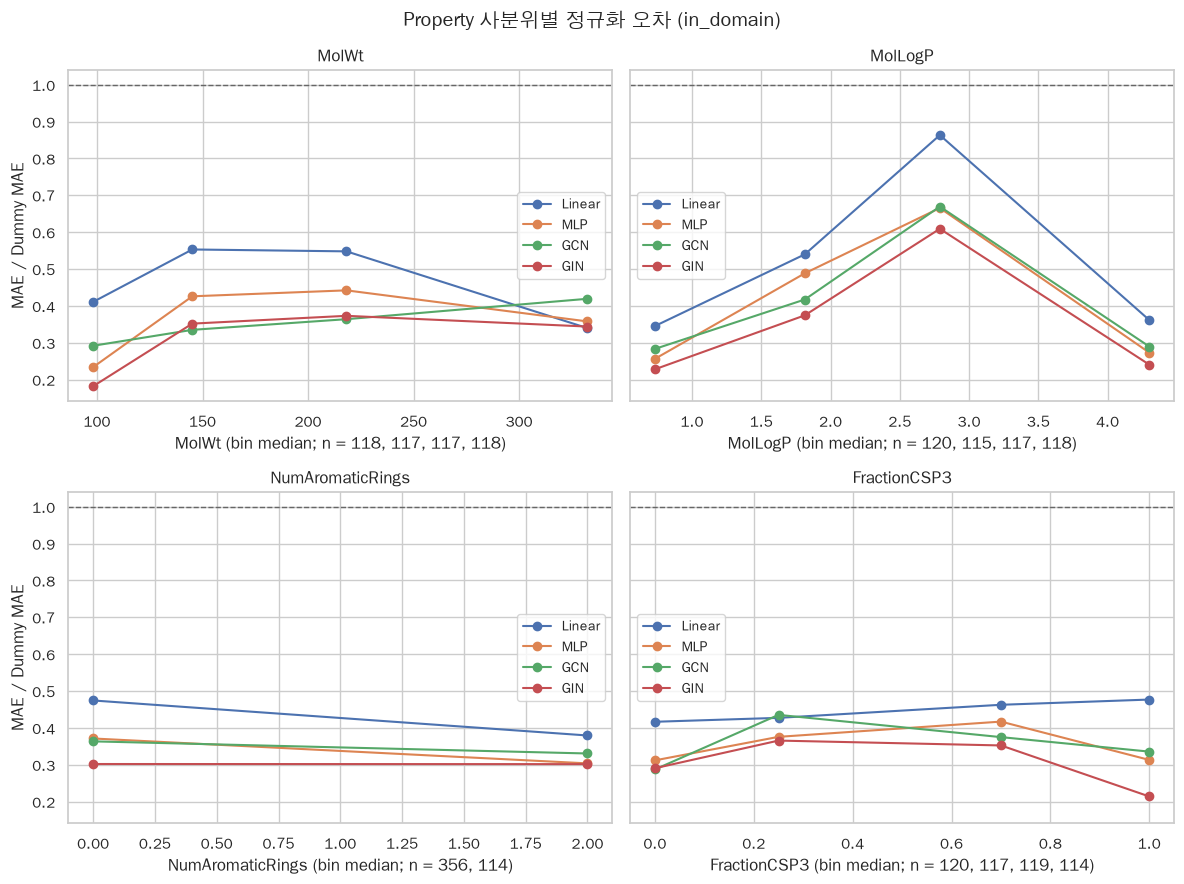

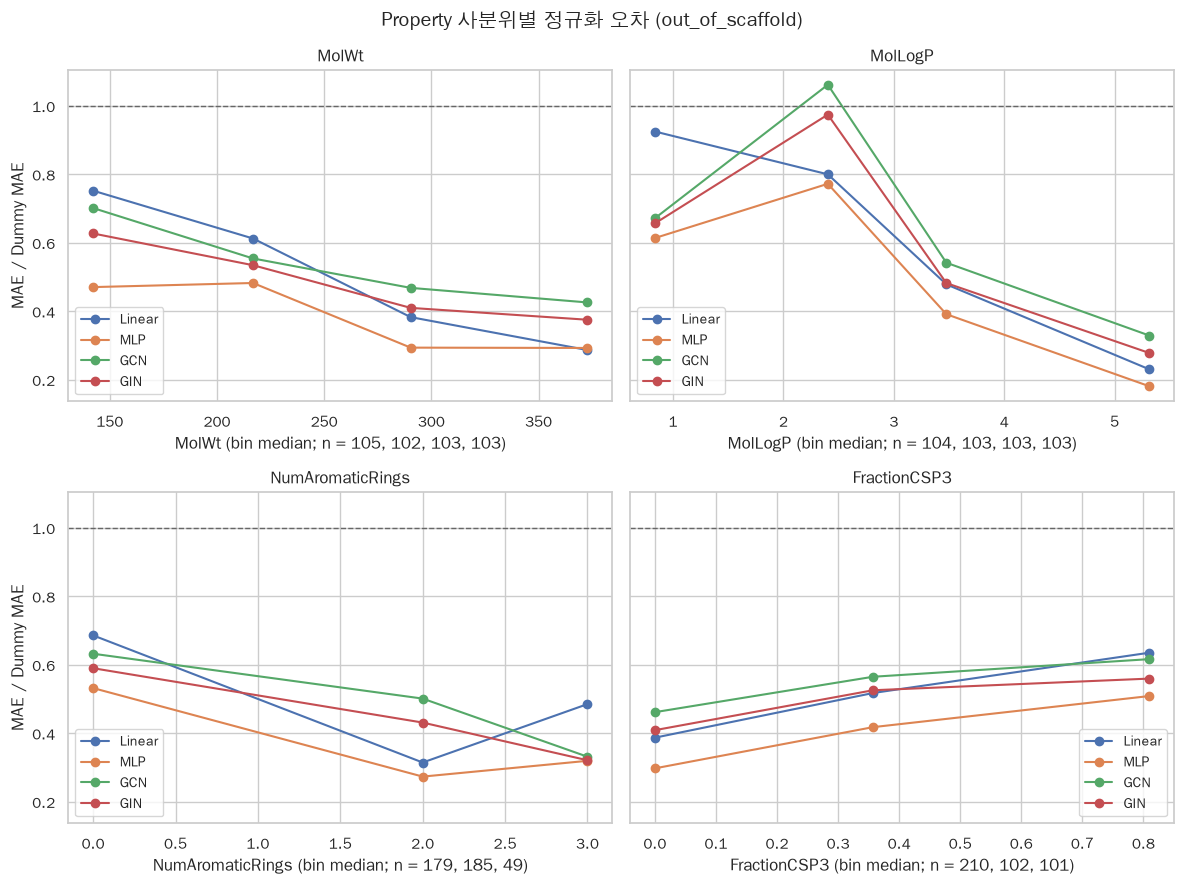

In [12]:
property_bins = property_bin_summary(profile, quantiles=CONFIG.property_quantiles)

figure_bins_in_domain = plot_property_error_bins(
    property_bins,
    properties=CONFIG.headline_properties,
    regime="in_domain",
    title="Property 사분위별 정규화 오차 (in_domain)",
)
figure_bins_out_of_scaffold = plot_property_error_bins(
    property_bins,
    properties=CONFIG.headline_properties,
    regime="out_of_scaffold",
    title="Property 사분위별 정규화 오차 (out_of_scaffold)",
)
plt.show()

## 8. 다변량: property는 similarity 위에 무엇을 더하는가

13개 property가 서로 겹쳐 있으니 단일 상관만으로는 부족합니다. `|error|`를 property로 예측하는
gradient boosting 모델을 학습하되, 두 가지를 지킵니다.

1. **held-out $R^2$를 먼저 봅니다.** 0 이하라면 permutation importance 순위는 읽지 않습니다.
   collinear한 feature 13개를 준 모델은 예측력이 없어도 그럴듯한 순위를 만들어 냅니다.
2. **통제 변수를 feature로 넣습니다.** `baseline_absolute_error`(난이도)와
   `nearest_train_similarity`(3주차의 축)를 함께 넣으면, 질문이 "property가 그 둘 **위에**
   무엇을 더하는가"로 바뀝니다.

두 번 적합해 비교합니다: 통제 변수 포함 vs property만.

In [13]:
importance = pd.concat(
    [
        error_property_importance(
            profile,
            control_features=controls,
            folds=CONFIG.importance_folds,
            repeats=CONFIG.importance_repeats,
            seed=CONFIG.seed,
        )
        for controls in (CONFIG.control_features, ())
    ],
    ignore_index=True,
)

gate = importance.drop_duplicates(["regime", "model", "controls_included"])
gate.pivot_table(
    index=["regime", "model"],
    columns="controls_included",
    values=["cross_validated_r2", "out_of_fold_spearman"],
).round(3)

cross_validated_r2        out_of_fold_spearman       
controls_included                   False  True                 False  True 
regime          model                                                       
in_domain       GCN                 0.019  0.088                0.268  0.318
                GIN                 0.079  0.126                0.275  0.374
                Linear              0.346  0.521                0.484  0.584
                MLP                 0.080  0.241                0.327  0.425
out_of_scaffold GCN                 0.158  0.277                0.307  0.408
                GIN                 0.082  0.228                0.237  0.346
                Linear              0.206  0.333                0.466  0.594
                MLP                 0.125  0.195                0.332  0.391

$R^2$가 모두 0보다 크므로 순위를 읽어도 됩니다 — 다만 크지는 않습니다. Property만으로도
약한 신호는 있고, 통제 변수를 넣으면 늘어납니다. 어느 feature가 그 상승분을 만드는지 봅니다.

In [14]:
for regime in ("in_domain", "out_of_scaffold"):
    panel = importance[
        (importance["regime"] == regime)
        & (importance["model"] == "GIN")
        & importance["controls_included"]
    ].sort_values("importance_mean", ascending=False)
    print(f"\n{regime} / GIN 상위 feature")
    print(panel[["feature", "is_control", "importance_mean", "importance_std"]].head(5).to_string(index=False))


in_domain / GIN 상위 feature
                 feature  is_control  importance_mean  importance_std
                   MolWt       False         0.153231        0.089038
 baseline_absolute_error        True         0.133882        0.032415
nearest_train_similarity        True         0.122952        0.063040
                    TPSA       False         0.051376        0.028804
          HeavyAtomCount       False         0.023817        0.010711

out_of_scaffold / GIN 상위 feature
                 feature  is_control  importance_mean  importance_std
 baseline_absolute_error        True         0.586797        0.136450
nearest_train_similarity        True         0.174059        0.071338
                    TPSA       False         0.099836        0.053775
            FractionCSP3       False         0.074310        0.044247
    AromaticAtomFraction       False         0.063761        0.043048


두 regime의 대비가 이 절의 결론입니다.

- `in_domain`에서는 **MolWt가 두 통제 변수보다 위**에 옵니다. 익숙한 골격 안에서도 GNN에게는
  분자 크기 자체가 고유한 약점입니다.
- `out_of_scaffold`에서는 **통제 변수 두 개가 상위를 독점**하고 property는 뒤로 밀립니다. 골격이
  낯설어지면 오차를 지배하는 것은 난이도와 novelty이고, property는 할 말이 거의 없습니다.

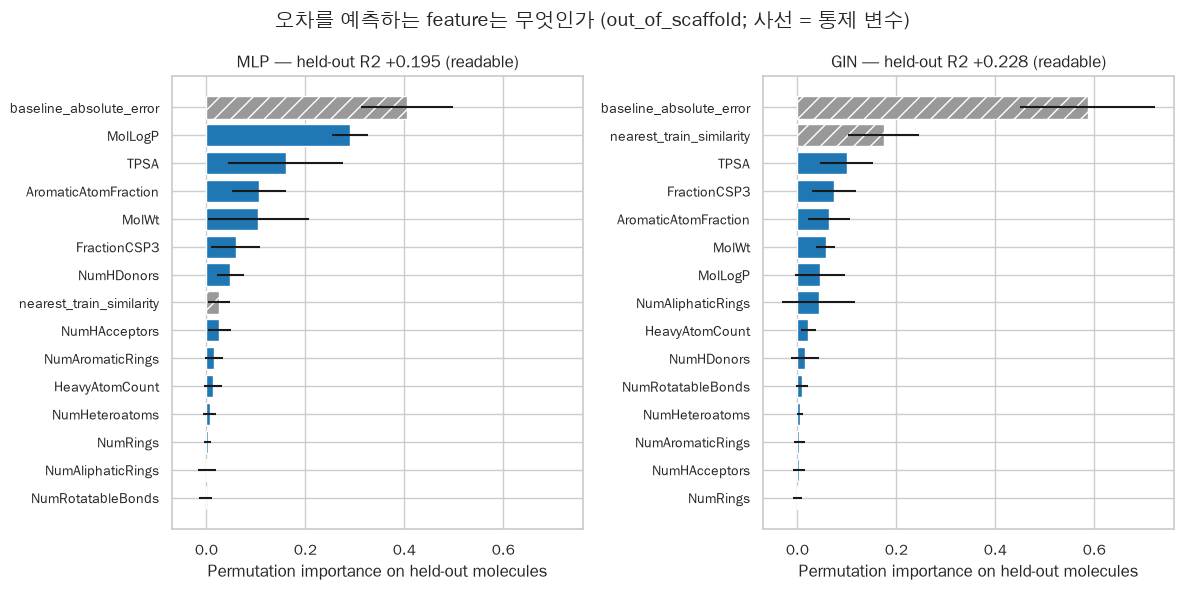

In [15]:
figure_importance = plot_error_property_importance(
    importance,
    regime="out_of_scaffold",
    models=CONFIG.diagnostic_models,
    title="오차를 예측하는 feature는 무엇인가 (out_of_scaffold; 사선 = 통제 변수)",
)
plt.show()

## 9. 핵심 질문: GIN과 MLP는 같은 분자에서 틀리는가

이번 주의 가장 중요한 표입니다. 두 가설을 구분합니다.

- **H1** 두 모델이 **같은** 분자에서 틀린다 → 어려운 화학이거나 label noise. 표현을 바꿔도 못 고칩니다.
- **H2** 두 모델이 **다른** 분자에서 틀린다 → 표현 방식 고유의 약점.

`same_family`(같은 표현을 쓰는 쌍)와 교차 쌍을 나란히 놓고 봅니다.

In [16]:
agreement = model_error_agreement(
    profile, samples=CONFIG.bootstrap_samples, seed=CONFIG.seed
)

agreement[
    (agreement["regime"] == "out_of_scaffold") & (agreement["model_a"] != "Dummy (mean)")
][
    [
        "model_a",
        "model_b",
        "same_family",
        "molecules",
        "spearman",
        "ci_low",
        "ci_high",
        "shared_worst_fraction",
    ]
].sort_values("spearman", ascending=False)

,model_a,model_b,same_family,molecules,spearman,ci_low,ci_high,shared_worst_fraction
19,GCN,GIN,True,413,0.679279,0.611934,0.736399,0.756098
14,Linear,MLP,True,413,0.433915,0.348493,0.515181,0.512195
18,MLP,GIN,False,413,0.253644,0.153681,0.341510,0.268293
17,MLP,GCN,False,413,0.193999,0.096630,0.288656,0.243902
16,Linear,GIN,False,413,0.173420,0.075483,0.267811,0.268293
15,Linear,GCN,False,413,0.071075,-0.026595,0.169126,0.195122


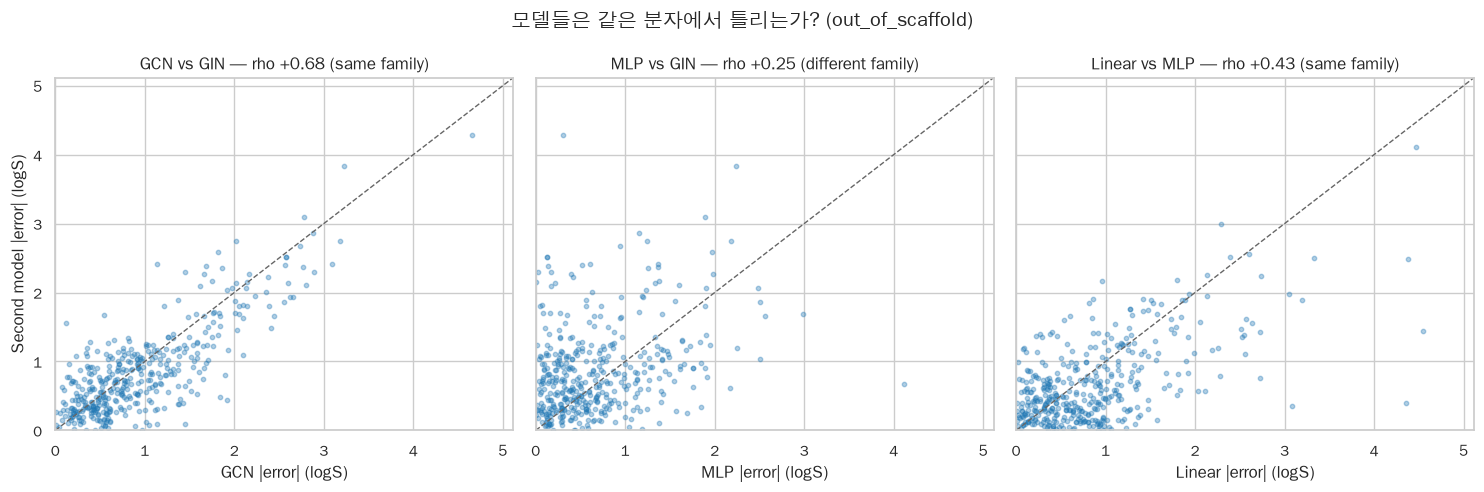

In [17]:
figure_agreement = plot_model_error_agreement(
    profile, title="모델들은 같은 분자에서 틀리는가? (out_of_scaffold)"
)
plt.show()

**답은 H2입니다.** 같은 표현을 쓰는 GCN↔GIN은 강하게 일치하고(최악 10%의 76%를 공유),
표현이 다른 MLP↔GIN은 약하게만 일치합니다. "어려운 분자"라는 보편적 집합이 있다면 모든 쌍의
상관이 비슷해야 합니다. 그렇지 않다는 것은 실패가 **표현 방식에 묶여 있다**는 뜻입니다.

구체적으로 어떤 분자에서 갈리는지 봅니다.

In [18]:
disagreement = model_error_disagreement(
    profile, models=CONFIG.diagnostic_models, regime="out_of_scaffold", top_n=5
)
disagreement[
    [
        "favours",
        "rank",
        "smiles",
        "actual",
        "absolute_error_a",
        "absolute_error_b",
        "MolWt",
        "MolLogP",
        "NumAromaticRings",
        "nearest_train_similarity",
    ]
]

,favours,rank,smiles,actual,absolute_error_a,absolute_error_b,MolWt,MolLogP,NumAromaticRings,nearest_train_similarity
0,GIN,1,OC(CC(c1ccccc1)c3c(O)c2ccccc2oc3=O)c4ccc(cc4)c...,-4.445,4.11810,0.6709,527.414,7.18370,5.0,0.43765
1,GIN,2,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,2.16760,0.6138,457.432,-3.10802,1.0,0.36760
2,GIN,3,COc1cc(cc(OC)c1O)C6C2C(COC2=O)C(OC4OC3COC(C)OC...,-3.571,1.84815,0.3345,588.562,1.33860,2.0,0.20000
3,GIN,4,C1c2ccccc2c3cc4ccccc4cc13,-8.040,2.50230,1.0311,216.283,4.41100,3.0,0.55260
4,GIN,5,c1ccc2c(c1)[nH]c3ccccc32,-5.270,1.69318,0.2463,167.211,3.32110,3.0,0.36840
5,MLP,1,Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,-11.600,0.30780,4.2814,498.662,9.88760,2.0,0.38460
6,MLP,2,ClC(Cl)C(c1ccc(Cl)cc1)c2ccc(Cl)cc2,-7.200,0.12830,2.5143,320.046,5.92900,2.0,0.47060
7,MLP,3,ClC(Cl)C(c1ccc(Cl)cc1)c2ccc(Cl)cc2,-7.200,0.12830,2.5143,320.046,5.92900,2.0,0.47060
8,MLP,4,C1=Cc2cccc3cccc1c23,-3.960,0.02650,2.2961,152.196,3.32360,2.0,0.47370
9,MLP,5,c2ccc1NCCc1c2,-1.040,0.14220,2.3902,119.167,1.65460,1.0,0.39130


패턴이 읽힙니다. **MLP가 이기는** 분자들은 염소가 많이 붙은 고-logP 분자들입니다 —
descriptor 모델은 logP가 극단적으로 크면 잘 녹지 않는다는 **단조 물리 규칙**을 그대로 외삽할 수
있습니다. **GIN이 이기는** 분자들은 여러 개의 fused ring이나 당·steroid 골격처럼 구조가 복잡한
쪽입니다 — 여기서는 graph topology가 실제로 도움이 됩니다.

## 10. 부호 있는 오차: 평균으로의 수축

지금까지는 `|error|`만 봤습니다. 부호를 보면 다른 진단이 나옵니다. `predicted ≈ slope × actual`을
적합해 기울기가 1보다 작으면 모델이 **target 범위를 압축**하고 있다는 뜻입니다.

In [19]:
shrinkage = shrinkage_fit(profile)
shrinkage[
    [
        "regime",
        "model",
        "slope",
        "prediction_std_ratio",
        "mean_residual",
        "low_solubility_bias",
        "high_solubility_bias",
    ]
]

,regime,model,slope,prediction_std_ratio,mean_residual,low_solubility_bias,high_solubility_bias
0,in_domain,Dummy (mean),-0.000477,0.007203,-0.007522,2.870647,-2.572119
1,in_domain,Linear,0.760528,0.854087,0.054372,0.761174,-0.597633
2,in_domain,MLP,0.860249,0.917548,0.060226,0.500910,-0.318324
3,in_domain,GCN,0.820391,0.932153,0.036298,0.625214,-0.449702
4,in_domain,GIN,0.867119,0.914133,0.022353,0.427821,-0.263323
5,out_of_scaffold,Dummy (mean),-0.012038,0.037889,1.176853,3.958674,-1.332349
6,out_of_scaffold,Linear,0.878740,1.016671,0.277710,0.580258,0.096367
7,out_of_scaffold,MLP,0.926539,1.016859,0.098168,0.196828,-0.090465
8,out_of_scaffold,GCN,0.687277,0.825862,0.214097,1.031938,-0.471089
9,out_of_scaffold,GIN,0.738204,0.856243,0.134218,0.860517,-0.399075


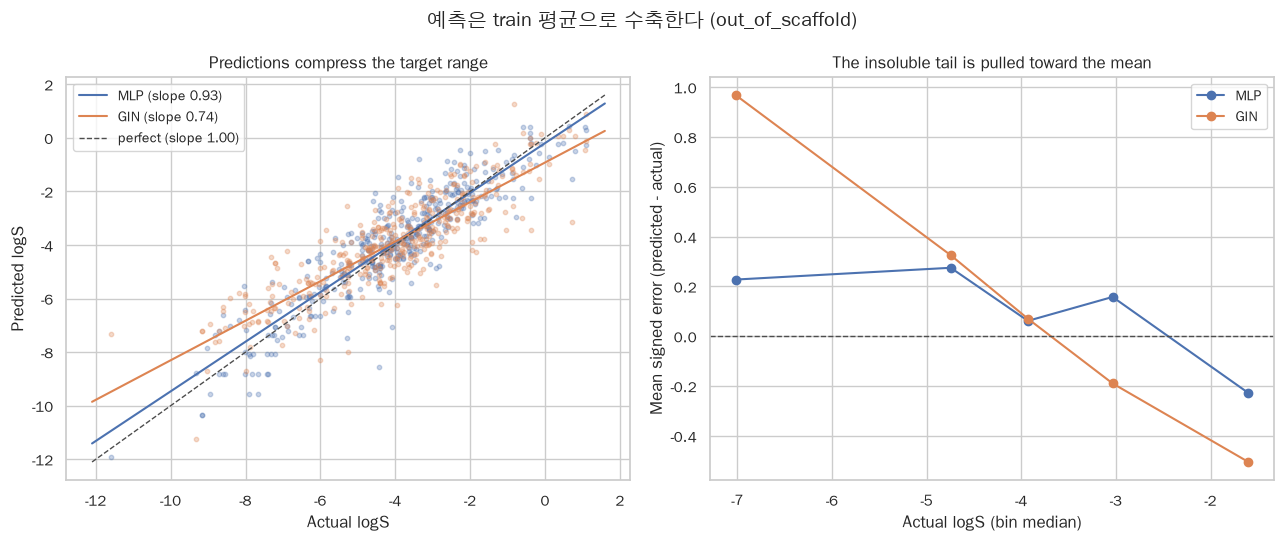

In [20]:
figure_shrinkage = plot_residual_shrinkage(
    profile, models=CONFIG.diagnostic_models, title="예측은 train 평균으로 수축한다 (out_of_scaffold)"
)
plt.show()

모든 모델의 기울기가 1보다 작고, `low_solubility_bias`는 양수 · `high_solubility_bias`는 음수입니다.
**잘 안 녹는 분자는 실제보다 잘 녹는다고, 잘 녹는 분자는 덜 녹는다고 예측합니다.**

사용자가 든 예 — true −4.0, pred −1.7 — 는 예외적 outlier가 아니라 **이 기울기의 당연한 결과**
입니다. 그리고 graph 모델(GIN 0.74)이 descriptor 모델(MLP 0.93)보다 훨씬 심하게 수축합니다.

## 11. Scaffold 단위로 무너지는 곳

`normalized_mean_absolute_error > 1.0`인 scaffold는 그 골격에서 모델이 **평균을 찍는 것보다
못하다**는 뜻입니다.

In [21]:
from ai4sci_molecule.week3 import scaffold_table

counts = scaffold_table(smiles).set_index("scaffold")["molecules"]
scaffold_errors = scaffold_error_table(
    profile, scaffold_counts=counts, minimum_molecules=CONFIG.minimum_scaffold_molecules
)

panel = scaffold_errors[
    (scaffold_errors["regime"] == "out_of_scaffold") & (scaffold_errors["model"] == "GIN")
]
print(f"≥{CONFIG.minimum_scaffold_molecules}분자 scaffold: {len(panel)}개")
print(f"그중 평균 예측보다 못한 scaffold: {int((panel['normalized_mean_absolute_error'] > 1).sum())}개")
panel[
    [
        "scaffold",
        "molecules",
        "dataset_molecules",
        "mean_absolute_error",
        "baseline_mean_absolute_error",
        "normalized_mean_absolute_error",
    ]
].head(10)

≥3분자 scaffold: 30개
그중 평균 예측보다 못한 scaffold: 5개


,scaffold,molecules,dataset_molecules,mean_absolute_error,baseline_mean_absolute_error,normalized_mean_absolute_error
225,c1ccc2ncccc2c1,5,5.0,1.155620,0.721650,1.601358
226,O=c1cccnn1-c1ccccc1,3,3.0,0.905300,0.621633,1.456325
227,c1ncncn1,16,16.0,1.097604,0.794854,1.380887
228,O=c1cc[nH]n1-c1ccccc1,3,3.0,3.094493,2.831600,1.092843
229,C1=CCCCC1,3,3.0,0.651333,0.644333,1.010864
230,O=C1C=CCCC1,3,3.0,1.437983,1.584767,0.907379
231,c1ccc2scnc2c1,3,3.0,0.789500,0.877133,0.900091
232,c1ccc2c(c1)CCO2,3,3.0,0.763733,0.914633,0.835016
233,O=C1Nc2cccnc2Nc2ncccc21,6,6.0,0.477267,0.790167,0.604008
234,C1CCCCCCC1,3,3.0,0.714772,1.192889,0.599194


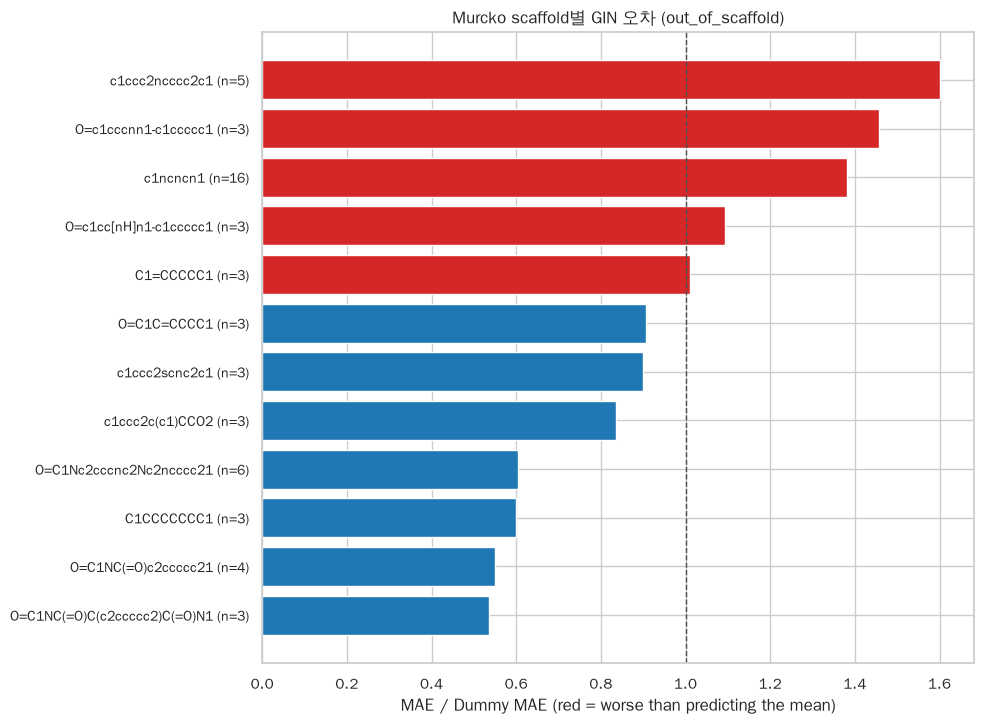

In [22]:
figure_scaffold = plot_scaffold_errors(
    scaffold_errors, model=CONFIG.case_model, title="Murcko scaffold별 GIN 오차 (out_of_scaffold)"
)
plt.show()

## 12. 분자 A와 분자 B

마지막으로 가장 못 맞춘 분자와 가장 잘 맞춘 분자를 나란히 놓습니다. "가장 잘 맞춘" 쪽은
난이도가 0.25 logS 이상인 분자로 제한합니다 — 그러지 않으면 그냥 train 평균에 앉아 있는
분자들이 뽑혀서 아무것도 배울 수 없습니다.

In [23]:
cases = case_studies(profile, model=CONFIG.case_model, top_n=CONFIG.case_count)
cases[
    [
        "case",
        "rank",
        "smiles",
        "actual",
        "predicted_mean",
        "absolute_error",
        "baseline_absolute_error",
        "nearest_train_similarity",
        "MolWt",
        "MolWt_percentile",
        "MolLogP",
    ]
]

,case,rank,smiles,actual,predicted_mean,absolute_error,baseline_absolute_error,nearest_train_similarity,MolWt,MolWt_percentile,MolLogP
0,worst,1,Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,-11.600,-7.318600,4.281400,8.846800,0.384600,498.662,98.305085,9.88760
1,worst,2,Cc1cc(=O)n(c2ccccc2)n1C,0.715,-3.124820,3.839820,3.637600,0.325000,188.230,27.845036,1.48442
2,worst,3,CN(C)c2c(C)n(C)n(c1ccccc1)c2=O,-0.364,-3.457480,3.093480,2.558600,0.303000,231.299,43.825666,1.55042
3,worst,4,C1C(O)CCC2(C)CC3CCC4(C)C5(C)CC6OCC(C)CC6OC5CC4...,-7.320,-4.458950,2.861050,4.419087,0.201425,414.630,93.462470,5.50880
4,worst,5,CC1OC(CC(O)C1O)OC2C(O)CC(OC2C)OC8C(O)CC(OC7CCC...,-5.293,-2.538967,2.754033,2.435900,0.262200,764.950,99.757869,3.24730
5,best,1,ON=Cc1ccc(o1)N(=O)=O,-2.190,-2.189600,0.000400,0.645600,0.523800,156.097,17.675545,0.99590
6,best,2,OC(Cn1cncn1)(c2ccc(F)cc2)c3ccccc3F,-3.370,-3.366300,0.003700,0.511400,0.267900,301.296,68.038741,2.49240
7,best,3,CCN2c1nc(Cl)ccc1N(C)C(=O)c3cccnc23,-4.114,-4.108500,0.005500,1.107000,0.652200,288.738,61.985472,2.87800
8,best,4,c1ccc2cc3ccccc3cc2c1,-6.350,-6.333100,0.016900,3.621300,0.909100,178.234,23.728814,3.99300
9,best,5,CC13CCC(=O)C=C1CCC4C2CCC(C(=O)CO)C2(CC(O)C34)C=O,-3.850,-3.882700,0.032700,1.042367,0.418267,360.450,82.808717,1.84570


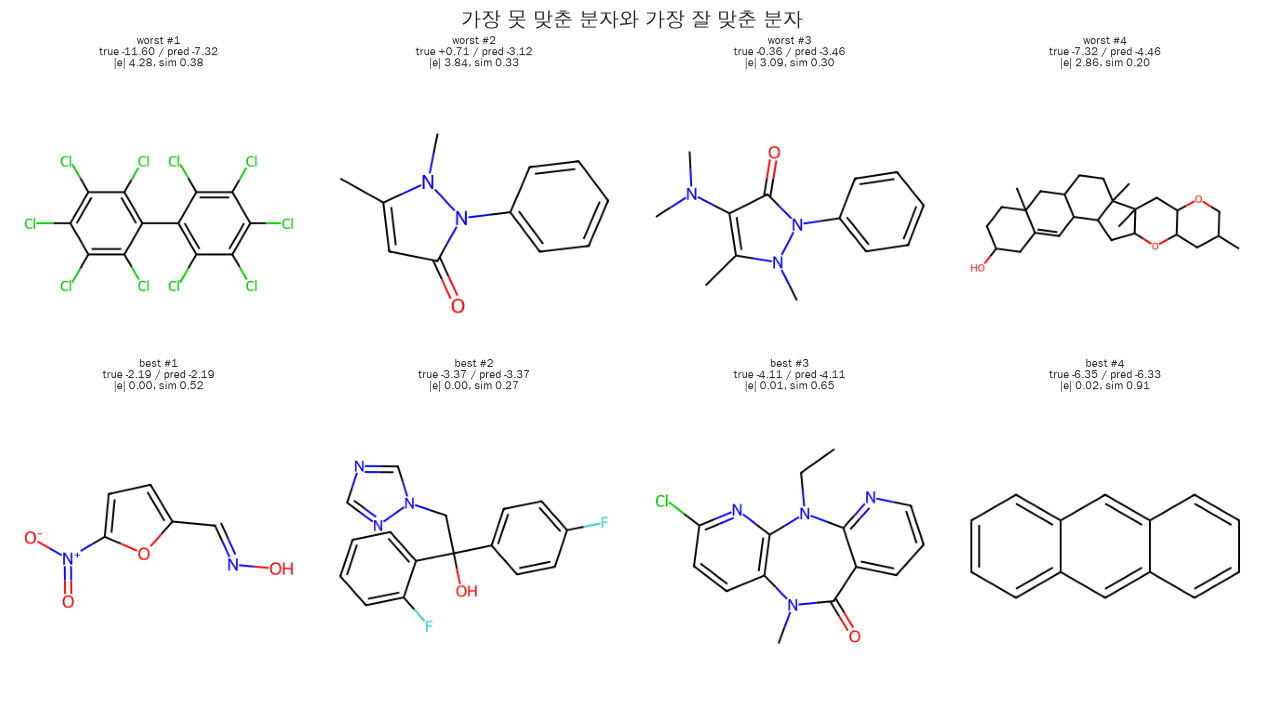

In [24]:
figure_cases = plot_case_study_structures(cases, title="가장 못 맞춘 분자와 가장 잘 맞춘 분자")
plt.show()

## 13. 결과물 저장

In [25]:
figures = {
    "property_collinearity": figure_collinearity,
    "property_error_correlation": figure_correlation,
    "property_error_bins_in_domain": figure_bins_in_domain,
    "property_error_bins_out_of_scaffold": figure_bins_out_of_scaffold,
    "property_importance": figure_importance,
    "model_error_agreement": figure_agreement,
    "residual_shrinkage": figure_shrinkage,
    "scaffold_errors": figure_scaffold,
    "case_study_structures": figure_cases,
}
for name, path in save_figures(figures, RESULTS_DIRECTORY / "figures").items():
    print(f"{name}: {path}")

property_collinearity: ../results/week4/figures/property_collinearity.png
property_error_correlation: ../results/week4/figures/property_error_correlation.png
property_error_bins_in_domain: ../results/week4/figures/property_error_bins_in_domain.png
property_error_bins_out_of_scaffold: ../results/week4/figures/property_error_bins_out_of_scaffold.png
property_importance: ../results/week4/figures/property_importance.png
model_error_agreement: ../results/week4/figures/model_error_agreement.png
residual_shrinkage: ../results/week4/figures/residual_shrinkage.png
scaffold_errors: ../results/week4/figures/scaffold_errors.png
case_study_structures: ../results/week4/figures/case_study_structures.png


## 14. 결론

네 줄로 요약하면:

1. **익숙한 골격 안에서는 크기가 곧 약점이다.** `in_domain`에서 GIN의 오차는 MolWt와 상관하고
   (Dummy는 평평), 다변량 모델에서도 MolWt가 난이도·similarity보다 위에 옵니다.
2. **골격이 낯설어지면 property 축이 침묵한다.** 오차를 지배하는 것은 난이도와 novelty이고,
   GIN은 어디서나 균일하게 나쁩니다.
3. **같은 표현끼리 같은 분자에서 틀린다.** GCN↔GIN은 강하게, MLP↔GIN은 약하게 일치 →
   어려운 화학이 아니라 **표현의 실패**.
4. **모두 평균으로 수축하고, graph 모델이 더 심하다.** GIN 기울기 0.74 vs MLP 0.93.

효과 크기는 작습니다(ρ ≈ 0.2–0.3). 오차의 지배적 축은 여전히 3주차의 scaffold novelty입니다.
해석과 한계는 [`reports/week4.md`](../reports/week4.md)에 정리해 두었습니다.

In [26]:
print(f"{'항목':<34}{'값':>26}")
print("-" * 60)

molwt = correlations[
    (correlations["regime"] == "in_domain")
    & (correlations["model"] == "GIN")
    & (correlations["property"] == "MolWt")
].iloc[0]
print(f"{'in_domain GIN rho(MolWt)':<34}{molwt['spearman']:>+26.3f}")
interval = "[{:+.3f}, {:+.3f}]".format(molwt["ci_low"], molwt["ci_high"])
print(f"{'  95% CI':<34}{interval:>26}")
print(f"{'  Dummy 통제군':<34}{molwt['baseline_spearman']:>+26.3f}")
print(f"{'  난이도·similarity 통제 후':<34}{molwt['partial_spearman']:>+26.3f}")

panel = agreement[agreement["regime"] == "out_of_scaffold"].set_index(["model_a", "model_b"])
print(f"{'GCN-GIN 오차상관 (같은 family)':<34}{panel.loc[('GCN', 'GIN'), 'spearman']:>+26.3f}")
print(f"{'MLP-GIN 오차상관 (다른 family)':<34}{panel.loc[('MLP', 'GIN'), 'spearman']:>+26.3f}")
print(f"{'GCN-GIN 최악 10% 공유':<34}{panel.loc[('GCN', 'GIN'), 'shared_worst_fraction']:>26.3f}")

slopes = shrinkage[shrinkage["regime"] == "out_of_scaffold"].set_index("model")["slope"]
print(f"{'shrinkage 기울기 GIN':<34}{slopes['GIN']:>26.3f}")
print(f"{'shrinkage 기울기 MLP':<34}{slopes['MLP']:>26.3f}")

r2 = gate[(gate["regime"] == "out_of_scaffold") & (gate["model"] == "GIN")].set_index(
    "controls_included"
)["cross_validated_r2"]
print(f"{'다변량 R2 (property만)':<34}{r2[False]:>+26.3f}")
print(f"{'다변량 R2 (통제 변수 포함)':<34}{r2[True]:>+26.3f}")

항목                                                         값
------------------------------------------------------------
in_domain GIN rho(MolWt)                              +0.265
  95% CI                                    [+0.180, +0.352]
  Dummy 통제군                                           -0.055
  난이도·similarity 통제 후                                 +0.292
GCN-GIN 오차상관 (같은 family)                              +0.679
MLP-GIN 오차상관 (다른 family)                              +0.254
GCN-GIN 최악 10% 공유                                      0.756
shrinkage 기울기 GIN                                      0.738
shrinkage 기울기 MLP                                      0.927
다변량 R2 (property만)                                    +0.082
다변량 R2 (통제 변수 포함)                                     +0.228
